In [1]:
from utils import initialize_environment
hf_token = initialize_environment()

import pandas as pd
from data import DataProcessor
from preprocessing import DataAnalyzer  
from features import BoW, TFIDF, Word2VecExtractor, PreTrainedWord2Vec
from models import LogisticClassifier, NaiveBayesClassifier, SVMClassifier
from trainer_utils import ModelTrainer
from evaluation.create_confusion_matrix import ConfusionMatrixCreator

Τρέχων φάκελος εργασίας: c:\Users\Alekos\Desktop\NLP
Προειδοποίηση: Δεν βρέθηκε HF_TOKEN στο αρχείο .env


In [2]:
X, y, encoders, test_indices = DataProcessor().prepare_baseline_data()

processor = DataProcessor()
raw_data = processor.process_data(
    train_path='csv/train.csv', 
    val_path='csv/valid.csv', 
    test_path='csv/test.csv', 
    tokenize=False
)

train_df = raw_data['train_df']
val_df = raw_data['val_df']
test_df = raw_data['test_df']

all_results = []

In [3]:
#ΣΤΑΤΙΣΤΙΚΑ ΔΕΙΓΜΑΤΩΝ 
print(f"Πλήθος δειγμάτων Εκπαίδευσης (Train Set)    : {len(train_df)}")
print(f"Πλήθος δειγμάτων Επικύρωσης (Validation Set): {len(val_df)}")
print(f"Πλήθος δειγμάτων Δοκιμής (Test Set)         : {len(test_df)}")
print(f"Συνολικό Πλήθος Δειγμάτων Challenge         : {len(train_df) + len(val_df) + len(test_df)}")

Πλήθος δειγμάτων Εκπαίδευσης (Train Set)    : 5082
Πλήθος δειγμάτων Επικύρωσης (Validation Set): 565
Πλήθος δειγμάτων Δοκιμής (Test Set)         : 997
Συνολικό Πλήθος Δειγμάτων Challenge         : 6644



 Κατανομή των Hazard Categories


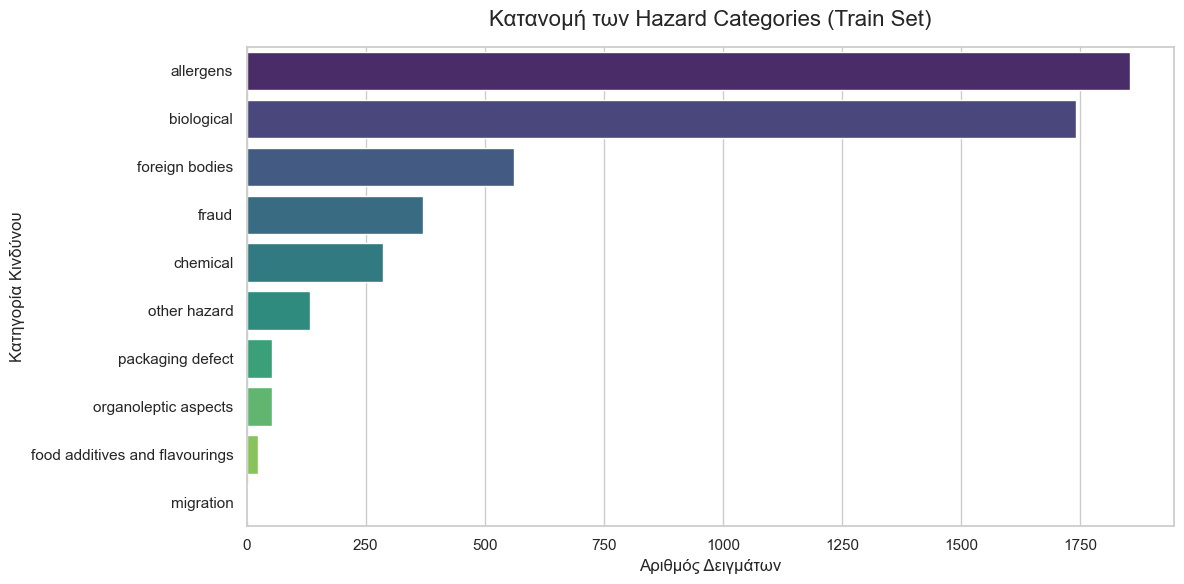


 Κατανομή των Product Categories


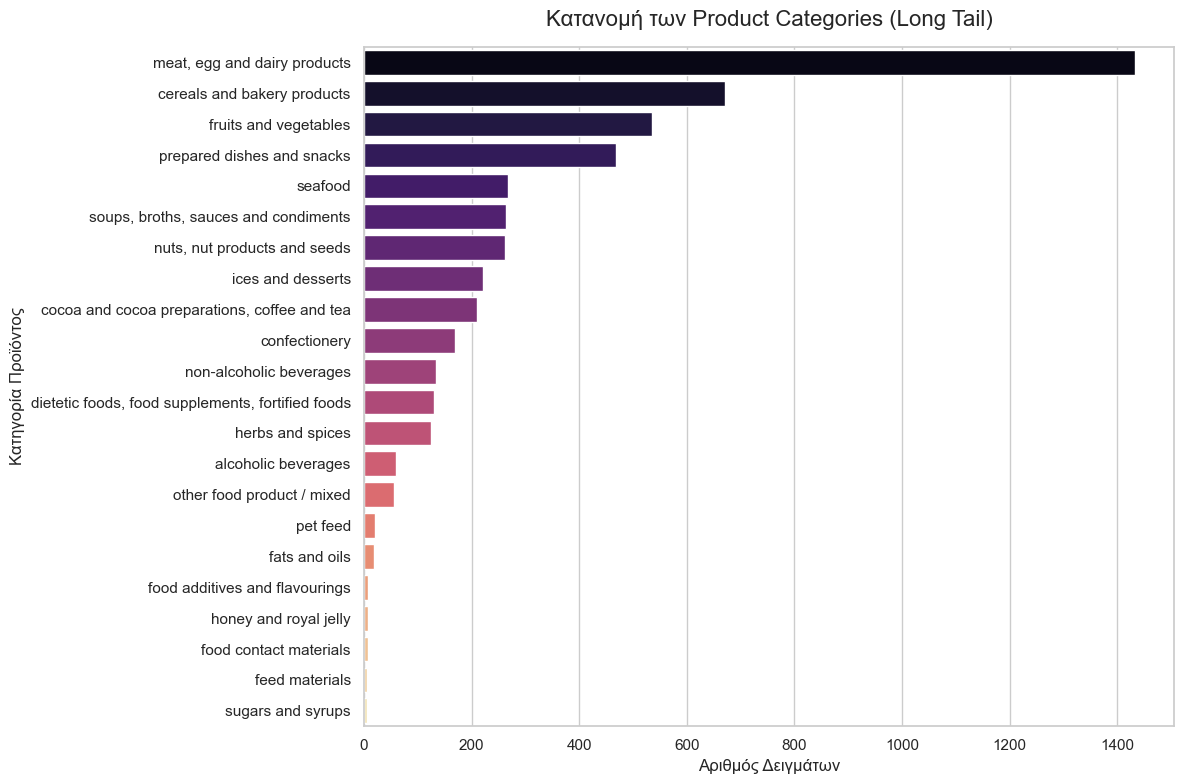

In [4]:
# ΔΙΑΓΡΑΜΜΑΤΑ ΚΑΤΑΝΟΜΗΣ

analyzer = DataAnalyzer()

print("\n Κατανομή των Hazard Categories")
analyzer.plot_hazard_distribution(train_df)

print("\n Κατανομή των Product Categories")
analyzer.plot_product_distribution(train_df)

In [5]:
# LOGISTIC REGRESSION 

#Bag of Words(BoW)
trainer_log_bow = ModelTrainer(extractor=BoW(max_features=5000, ngram_range=(1, 2)), classifier_class=LogisticClassifier)
st1_log_bow = trainer_log_bow.run_experiment(X, y, encoders, test_indices, export_name="log_reg_bow")
all_results.append({"Model": "Logistic Regression", "Feature": "Bag of Words (BoW)", "ST1 Score": st1_log_bow})

#TF-IDF
trainer_log_tfidf = ModelTrainer(extractor=TFIDF(max_features=5000, ngram_range=(1, 2)), classifier_class=LogisticClassifier)
st1_log_tfidf = trainer_log_tfidf.run_experiment(X, y, encoders, test_indices, export_name="log_reg_tfidf")
all_results.append({"Model": "Logistic Regression", "Feature": "TF-IDF", "ST1 Score": st1_log_tfidf})

#Custom Word2Vec 
trainer_log_w2v_custom = ModelTrainer(extractor=Word2VecExtractor(vector_size=100), classifier_class=LogisticClassifier)
st1_log_w2v_custom = trainer_log_w2v_custom.run_experiment(X, y, encoders, test_indices, export_name="log_reg_w2v_custom")
all_results.append({"Model": "Logistic Regression", "Feature": "Custom Word2Vec", "ST1 Score": st1_log_w2v_custom})

#Pre-trained Word2Vec
trainer_log_w2v_pre = ModelTrainer(extractor=PreTrainedWord2Vec(), classifier_class=LogisticClassifier)
st1_log_w2v_pre = trainer_log_w2v_pre.run_experiment(X, y, encoders, test_indices, export_name="log_reg_w2v_pretrained")
all_results.append({"Model": "Logistic Regression", "Feature": "Google Word2Vec (Pre-trained)", "ST1 Score": st1_log_w2v_pre})

 Macro-F1 Score: 0.7076

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       207
           1       0.98      0.95      0.97       194
           2       0.77      0.82      0.79        28
           3       0.33      0.50      0.40         2
           4       0.91      0.98      0.95        63
           5       0.70      0.73      0.71        41
           7       0.67      0.50      0.57         8
           8       0.67      0.57      0.62        14
           9       0.43      0.38      0.40         8

    accuracy                           0.91       565
   macro avg       0.71      0.71      0.71       565
weighted avg       0.91      0.91      0.91       565

 Macro-F1 Score: 0.6726

              precision    recall  f1-score   support

           0       0.60      0.86      0.71         7
           1       0.69      0.69      0.69        75
           2       0.73      0.73      0.73        15
           3       0.53     

In [6]:
#NAIVE BAYES 
#Bag of Words (BoW)
trainer_nb_bow = ModelTrainer(extractor=BoW(max_features=5000, ngram_range=(1, 2)), classifier_class=NaiveBayesClassifier)
st1_nb_bow = trainer_nb_bow.run_experiment(X, y, encoders, test_indices, export_name="naive_bayes_bow")
all_results.append({"Model": "Naive Bayes (Default)", "Feature": "Bag of Words (BoW)", "ST1 Score": st1_nb_bow})

#TF-IDF (Alpha = 1.0)
trainer_nb_tfidf = ModelTrainer(extractor=TFIDF(max_features=5000, ngram_range=(1, 2)), classifier_class=NaiveBayesClassifier)
st1_nb_tfidf = trainer_nb_tfidf.run_experiment(X, y, encoders, test_indices, export_name="naive_bayes_tfidf")
all_results.append({"Model": "Naive Bayes (Default)", "Feature": "TF-IDF", "ST1 Score": st1_nb_tfidf})

#Alpha Tuning(TF-IDF)
alpha_values = [0.001, 0.01, 0.05, 0.1, 0.5]
for a in alpha_values:
    trainer = ModelTrainer(
        extractor=TFIDF(max_features=5000, ngram_range=(1, 2)), 
        classifier_class=lambda: NaiveBayesClassifier(alpha=a)
    )
    score = trainer.run_experiment(X, y, encoders, test_indices, export_name=f"naive_bayes_tfidf_alpha_{a}")
    all_results.append({"Model": f"Naive Bayes (alpha={a})", "Feature": "TF-IDF", "ST1 Score": score})


--- Naive Bayes Evaluation ---
Macro-F1 Score: 0.4268


--- Naive Bayes Evaluation ---
Macro-F1 Score: 0.3106


 ΤΕΛΙΚΟ ST1 SCORE (naive_bayes_bow): 0.3687 <---
Το αρχείο 'csv/submission_naive_bayes_bow.csv' δημιουργήθηκε επιτυχώς (997 γραμμές).

--- Naive Bayes Evaluation ---
Macro-F1 Score: 0.4696


--- Naive Bayes Evaluation ---
Macro-F1 Score: 0.3100


 ΤΕΛΙΚΟ ST1 SCORE (naive_bayes_tfidf): 0.3898 <---
Το αρχείο 'csv/submission_naive_bayes_tfidf.csv' δημιουργήθηκε επιτυχώς (997 γραμμές).

--- Naive Bayes Evaluation ---
Macro-F1 Score: 0.5271


--- Naive Bayes Evaluation ---
Macro-F1 Score: 0.4088


 ΤΕΛΙΚΟ ST1 SCORE (naive_bayes_tfidf_alpha_0.001): 0.4679 <---
Το αρχείο 'csv/submission_naive_bayes_tfidf_alpha_0.001.csv' δημιουργήθηκε επιτυχώς (997 γραμμές).

--- Naive Bayes Evaluation ---
Macro-F1 Score: 0.4624


--- Naive Bayes Evaluation ---
Macro-F1 Score: 0.3649


 ΤΕΛΙΚΟ ST1 SCORE (naive_bayes_tfidf_alpha_0.01): 0.4137 <---
Το αρχείο 'csv/submission_naive_bayes_tfidf_alpha_0.

In [7]:
#SUPPORT VECTOR MACHINE(SVM)

#Bag of Words(BoW)
trainer_svm_bow = ModelTrainer(extractor=BoW(max_features=5000, ngram_range=(1, 2)), classifier_class=SVMClassifier)
st1_svm_bow = trainer_svm_bow.run_experiment(X, y, encoders, test_indices, export_name="svm_bow")
all_results.append({"Model": "SVM (Default)", "Feature": "Bag of Words (BoW)", "ST1 Score": st1_svm_bow})

#TF-IDF (C = 1.0)
trainer_svm_tfidf = ModelTrainer(extractor=TFIDF(max_features=5000, ngram_range=(1, 2)), classifier_class=SVMClassifier)
st1_svm_tfidf = trainer_svm_tfidf.run_experiment(X, y, encoders, test_indices, export_name="svm_tfidf")
all_results.append({"Model": "SVM (Default)", "Feature": "TF-IDF", "ST1 Score": st1_svm_tfidf})

#C Tuning(TF-IDF)
c_values = [0.01, 0.1, 0.5, 2.0, 5.0]
for c in c_values:
    trainer = ModelTrainer(
        extractor=TFIDF(max_features=5000, ngram_range=(1, 2)), 
        classifier_class=lambda: SVMClassifier(C=c)
    )
    score = trainer.run_experiment(X, y, encoders, test_indices, export_name=f"svm_tfidf_c_{c}")
    all_results.append({"Model": f"SVM (C={c})", "Feature": "TF-IDF", "ST1 Score": score})

Macro-F1 Score: 0.7001

              precision    recall  f1-score   support

           0       0.94      0.97      0.95       207
           1       0.97      0.96      0.97       194
           2       0.83      0.71      0.77        28
           3       0.50      0.50      0.50         2
           4       0.90      0.98      0.94        63
           5       0.67      0.68      0.67        41
           7       0.80      0.50      0.62         8
           8       0.62      0.57      0.59        14
           9       0.33      0.25      0.29         8

    accuracy                           0.91       565
   macro avg       0.73      0.68      0.70       565
weighted avg       0.90      0.91      0.90       565

Macro-F1 Score: 0.5948

              precision    recall  f1-score   support

           0       0.71      0.71      0.71         7
           1       0.60      0.59      0.59        75
           2       0.56      0.60      0.58        15
           3       0.73      0

In [8]:
results_df = pd.DataFrame(all_results)

results_df = results_df.sort_values(by="ST1 Score", ascending=False).reset_index(drop=True)

print(results_df.to_string(index=False))

best_model = results_df.iloc[0]
print(f"\n Best:{best_model['Model']} {best_model['Feature']} (Score: {best_model['ST1 Score']:.4f})")

                    Model                       Feature  ST1 Score
              SVM (C=5.0)                        TF-IDF   0.707770
      Logistic Regression            Bag of Words (BoW)   0.690098
              SVM (C=0.5)                        TF-IDF   0.686550
            SVM (Default)                        TF-IDF   0.677830
              SVM (C=2.0)                        TF-IDF   0.673404
            SVM (Default)            Bag of Words (BoW)   0.647450
              SVM (C=0.1)                        TF-IDF   0.614741
      Logistic Regression                        TF-IDF   0.601987
Naive Bayes (alpha=0.001)                        TF-IDF   0.467940
      Logistic Regression Google Word2Vec (Pre-trained)   0.459853
             SVM (C=0.01)                        TF-IDF   0.457936
  Naive Bayes (alpha=0.5)                        TF-IDF   0.457354
  Naive Bayes (alpha=0.1)                        TF-IDF   0.453533
      Logistic Regression               Custom Word2Vec   0.42

In [9]:
cm_creator = ConfusionMatrixCreator(
    train_df=train_df, 
    val_df=val_df, 
    target_col='hazard_label', 
    class_names=raw_data['le_hazard'].classes_
)

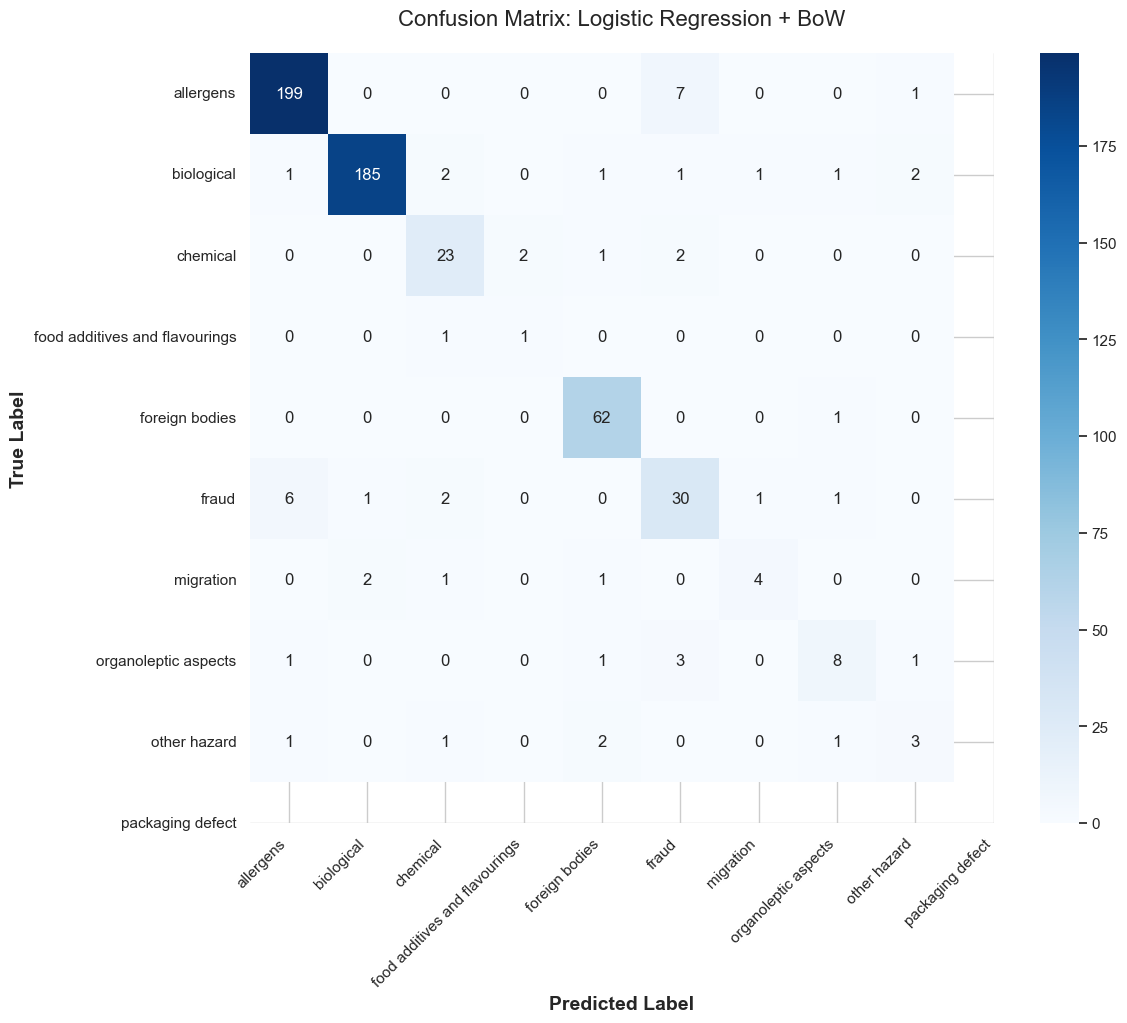

In [10]:
cm_creator.train_and_plot(
    classifier=LogisticClassifier(), 
    extractor=BoW(max_features=5000, ngram_range=(1, 2)), 
    title="Confusion Matrix: Logistic Regression + BoW", 
    filename="cm_top2_logreg_hazard.png"
)

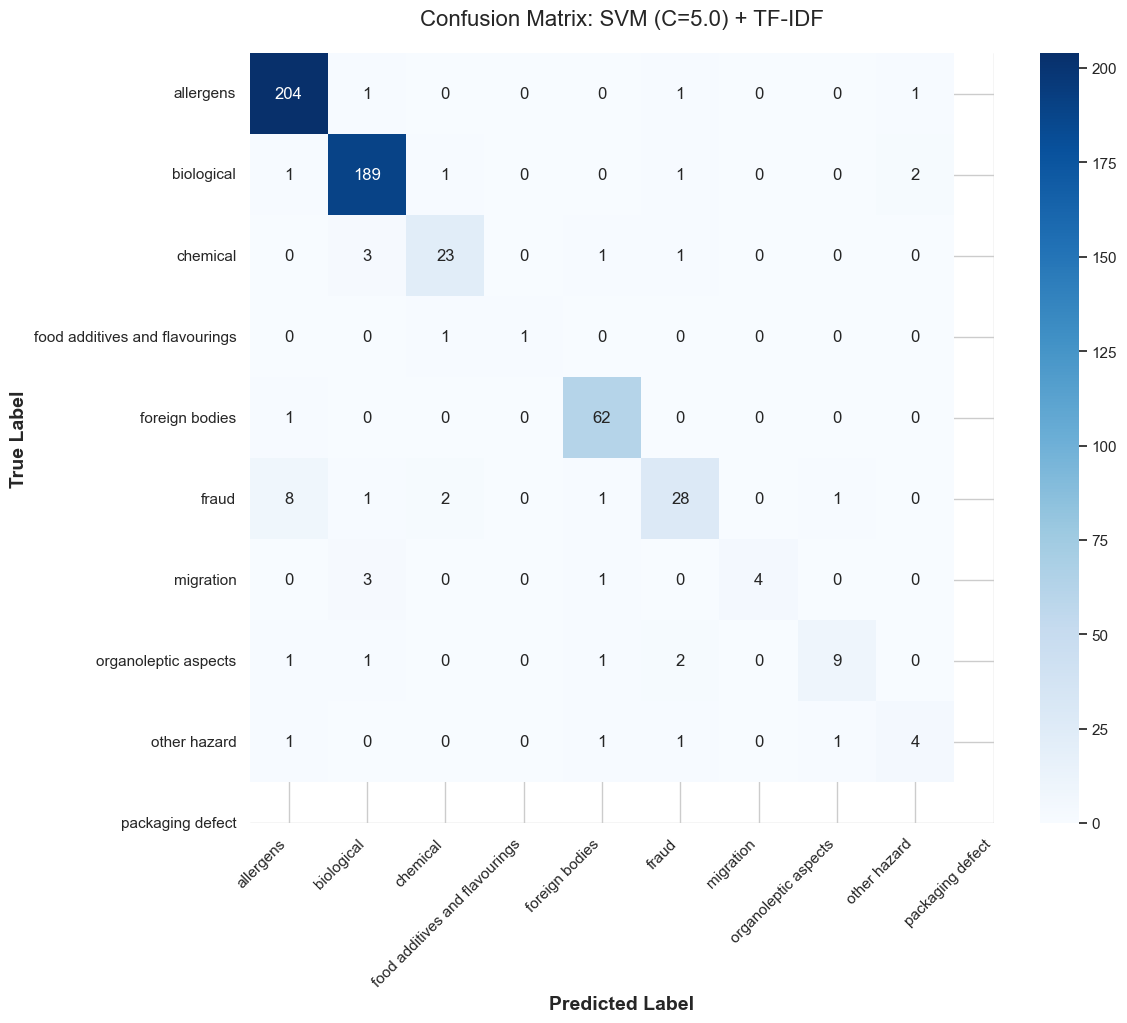

In [11]:
cm_creator.train_and_plot(
    classifier=SVMClassifier(C=5.0), 
    extractor=TFIDF(max_features=15000, ngram_range=(1, 2)), 
    title="Confusion Matrix: SVM (C=5.0) + TF-IDF", 
    filename="cm_top1_svm_hazard.png"
)